# 7장 Handling Buttons and Links

## 7.1 Where Are the Links?

In [1]:
from browser.html import HTMLParser, print_tree
from browser.css import DEFAULT_STYLE_SHEET, cascade_priority, style
from browser.layout import BlockLayout, LineLayout, TextLayout

# 1. 테스트용 HTML 문서 (책 7.1 예제와 동일)
html_content = """<html>
  <body>
    Here is some text that is
    <br>
    spread across multiple lines
  </body>
</html>"""

# 2. HTML 파싱 및 스타일 적용
nodes = HTMLParser(html_content).parse()
rules = DEFAULT_STYLE_SHEET.copy()
style(nodes, sorted(rules, key=cascade_priority))

# 3. body 태그에 대한 BlockLayout 생성 및 인라인 순회
body_node = nodes.children[0]
block = BlockLayout(body_node, parent=None, previous=None)
block.width = 800
block.new_line()
block.recurse(body_node)

# 4. 생성된 트리 출력
print("=== 1. 생성된 새로운 레이아웃 트리 (print_tree) ===")
print_tree(block)


=== 1. 생성된 새로운 레이아웃 트리 (print_tree) ===
 BlockLayout(<body>)
   LineLayout()
     TextLayout('Here')
     TextLayout('is')
     TextLayout('some')
     TextLayout('text')
     TextLayout('that')
     TextLayout('is')
   LineLayout()
     TextLayout('spread')
     TextLayout('across')
     TextLayout('multiple')
     TextLayout('lines')


## 7.2 Line Layout, Redux

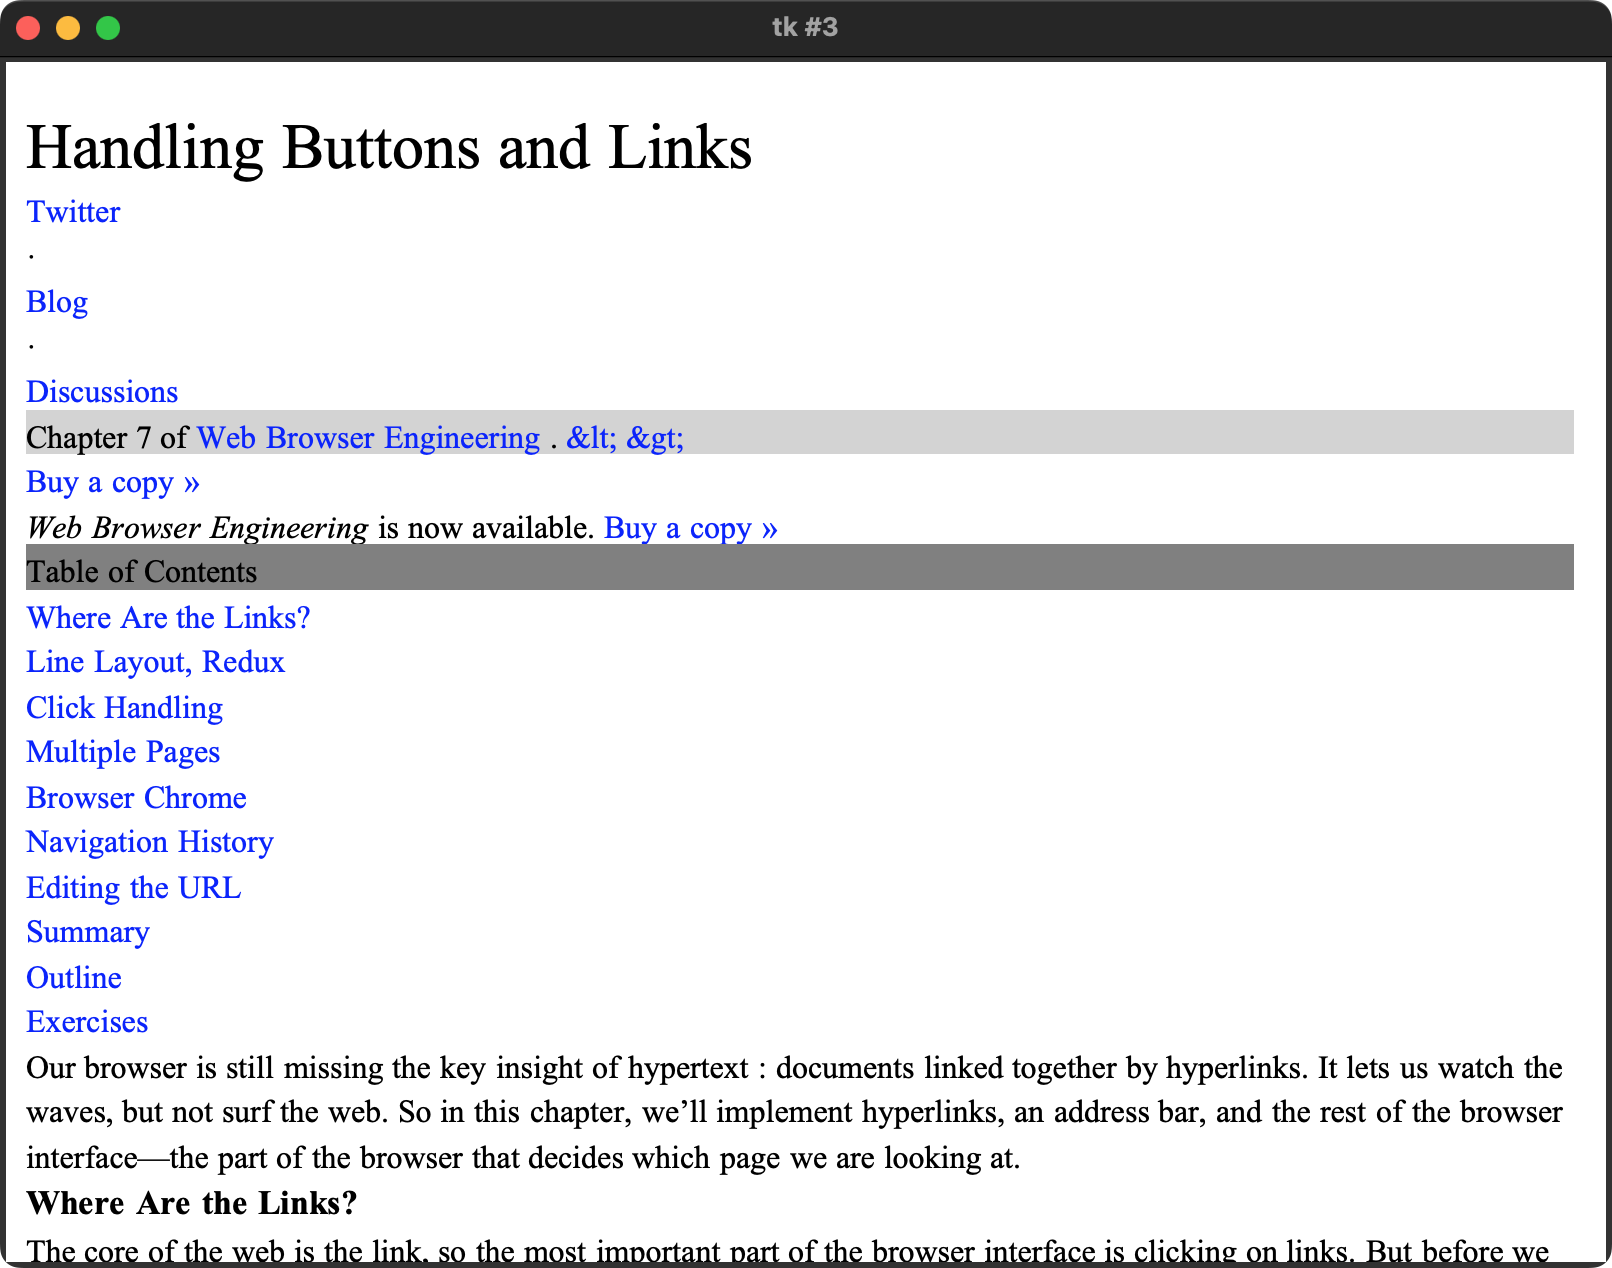

In [3]:
import time
import importlib
import browser.layout
import browser.browser

# 💡 layout.py 파일 수정을 주피터 메모리에 즉시 반영 (모듈 핫 리로드)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.url import URL
from browser.browser import Browser
from browser.layout import TextLayout, DrawRect
from browser.tk_capture import display_tk_window

# 1. 7.2 리팩터링 후 Browser 실행 및 실제 웹 페이지 로드
url = URL("https://browser.engineering/chrome.html")
browser = Browser()
browser.load(url)

# 2. Tkinter 윈도우 렌더링 동기화
for _ in range(10):
    browser.window.update_idletasks()
    browser.window.update()
    time.sleep(0.05)

# 3. 렌더링 결과 스크린샷 캡처 및 노트북 출력 (6장과 동일한 시각적 렌더링 검증)
display_tk_window(browser.window, settle_seconds=0.5)

# 4. 7.2의 핵심 가치 검증: 화면의 링크(<a>)들이 실제 TextLayout 객체로 크기와 좌표를 가지는지 확인
def find_links(layout_object, links=None):
    if links is None:
        links = []
    if isinstance(layout_object, TextLayout):
        node = layout_object.node
        curr = node
        while curr:
            if getattr(curr, "tag", None) == "a" and "href" in curr.attributes:
                links.append((layout_object, curr.attributes["href"]))
                break
            curr = curr.parent
    for child in layout_object.children:
        find_links(child, links)
    return links

link_objects = find_links(browser.document)
print(f"\n=== 7.2 핵심 검증: 레이아웃 트리에서 추출된 링크 단어 수: {len(link_objects)}개 ===")
for text_layout, href in link_objects[:8]:
    print(f"  단어: '{text_layout.word:<12}' | 좌표: (x={text_layout.x:>3}, y={text_layout.y:>4}, w={text_layout.width:>3}, h={text_layout.height:>2}) | URL: {href}")